In [5]:
import sys
import os
# Add the scripts folder to the path
sys.path.append(os.path.abspath("scripts"))

# Import functions
from data_processing import convert_all_nc4_to_csv, load_combined_dataframe, get_season
from spatial_analysis import (filter_by_africa_bounds, get_africa_shape, 
                              create_geodataframe_from_grid, clip_to_africa,
                              create_geodataframe_polygons)
from visualization import (plot_monthly_grid, plot_annual_mean_map, 
                           plot_seasonal_maps, plot_monthly_timeseries, 
                           )


In [6]:
# 1. Processing
convert_all_nc4_to_csv("data", "data_csv")

Processed 362 files.


In [7]:
df_all = load_combined_dataframe("data_csv")

In [8]:
# 2. DATA LOADING
df_africa = filter_by_africa_bounds(df_all)
df_africa["season"] = df_africa["month"].apply(get_season)  
africa_shape = get_africa_shape("data_shapefile/africa_boundaries.shp")

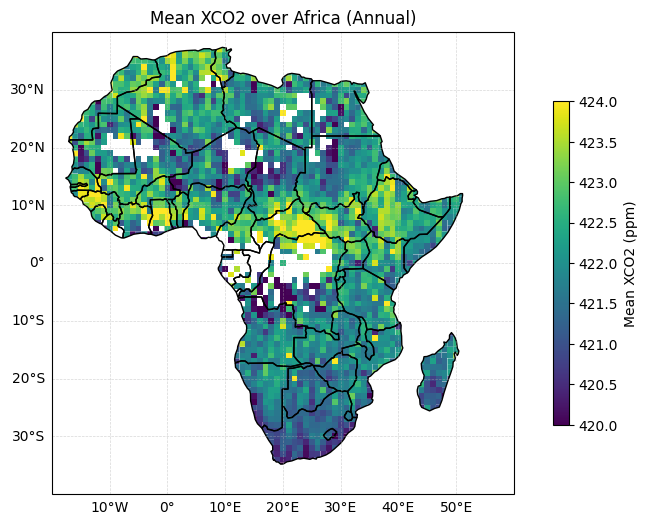

In [9]:
# 3. Annual Plot
gdf_poly = create_geodataframe_polygons(df_africa)
gdf_annual = clip_to_africa(gdf_poly, africa_shape)
plot_annual_mean_map(gdf_annual, africa_shape)

In [10]:
import geopandas as gpd
gdf_with_country = gpd.sjoin(
    gdf_annual, 
    africa_shape[['geometry', 'ADMIN']],  # ou le champ avec les noms des pays
    how='left',
    predicate='within'
)

# print(africa_shape.columns)
# print(africa_shape.head()) # le champs où il y a les noms des pays c'est "ADMIN"
print(len(africa_shape))
print(gdf_with_country['ADMIN'].unique())

50
<StringArray>
[                               nan,                     'South Africa',
                          'Namibia',                         'Botswana',
                       'Mozambique',                         'Zimbabwe',
                           'Angola',                           'Zambia',
 'Democratic Republic of the Congo',      'United Republic of Tanzania',
            'Republic of the Congo',         'Central African Republic',
                       'Madagascar',                            'Kenya',
                          'Somalia',                           'Uganda',
                      'South Sudan',                            'Gabon',
                'Equatorial Guinea',                         'Cameroon',
                          'Nigeria',                            'Sudan',
                             'Chad',                            'Niger',
                          'Algeria',                            'Libya',
                            'Egypt

In [11]:
country_section = {
    # 🌴 TROPICAL
    'Nigeria': 'Tropical',
    'Ghana': 'Tropical',
    'Ivory Coast': 'Tropical',
    'Liberia': 'Tropical',
    'Sierra Leone': 'Tropical',
    'Guinea': 'Tropical',
    'Guinea-Bissau': 'Tropical',
    'Cameroon': 'Tropical',
    'Central African Republic': 'Tropical',
    'Equatorial Guinea': 'Tropical',
    'Gabon': 'Tropical',
    'Republic of the Congo': 'Tropical',
    'Democratic Republic of the Congo': 'Tropical',
    'Uganda': 'Tropical',
    'Kenya': 'Tropical',
    'United Republic of Tanzania': 'Tropical',
    'Benin': 'Tropical',
    'Mozambique': 'Tropical',
    'Madagascar': 'Tropical',
    'Senegal': 'Tropical',
    'Zimbabwe': 'Tropical',
    'Zambia': 'Tropical',
    'Angola': 'Tropical',

    # 🌵 ARID (sahara, sahel)
    'Algeria': 'Arid',
    'Libya': 'Arid',
    'Egypt': 'Arid',
    'Sudan': 'Arid',
    'South Sudan': 'Arid',
    'Chad': 'Arid',
    'Niger': 'Arid',
    'Mali': 'Arid',
    'Mauritania': 'Arid',
    'Namibia': 'Arid',
    'Botswana': 'Arid',
    'Somalia': 'Arid',
    'Somaliland': 'Arid',
    'Eritrea': 'Arid',

    # 🌿 TEMPERATE (sud de l’Afrique)
    'South Africa': 'Temperate',

    # 🌊 MEDITERRANEAN (Nord Afrique)
    'Morocco': 'Mediterranean',
    'Tunisia': 'Mediterranean',

    # 🌍 TRANSITION 
    'Burkina Faso': 'Arid',
    'Ethiopia': 'Arid'
}
gdf_with_country['climate_zone'] = gdf_with_country['ADMIN'].map(country_section)

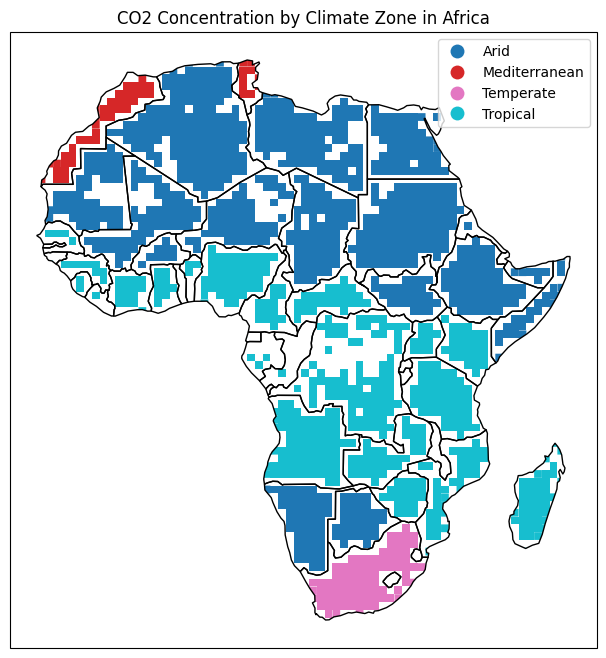

893
<StringArray>
[nan]
Length: 1, dtype: str


In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
gdf_with_country.plot(ax=ax, column='climate_zone', legend=True, categorical=True, cmap="tab10")
africa_shape.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
plt.title("CO2 Concentration by Climate Zone in Africa")
plt.show()

print(gdf_with_country['climate_zone'].isna().sum())
print(gdf_with_country[gdf_with_country['climate_zone'].isna()]['ADMIN'].unique())

In [13]:
zones = africa_shape.copy()

zones['climate_zone'] = zones['ADMIN'].map(country_section)

# enlever les pays non classés
zones_clean = zones.dropna(subset=['climate_zone'])

In [14]:
zones_dissolved = zones_clean.dissolve(by='climate_zone')

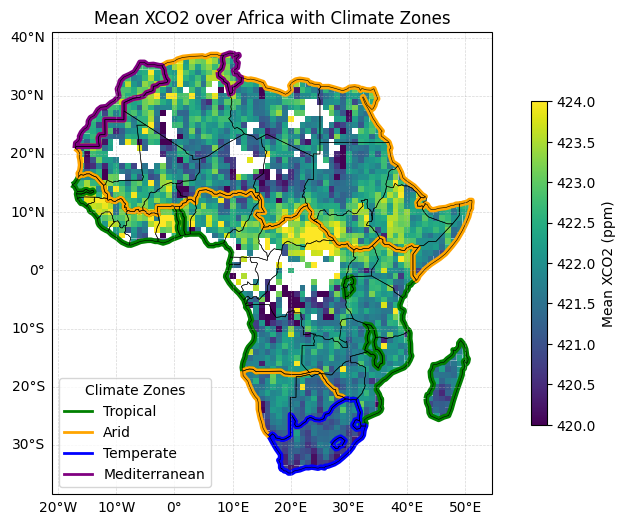

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# CO2 (ta carte principale)
gdf_annual.plot(
    ax=ax,
    column="xco2",
    cmap="viridis",
    vmin=420, vmax=424,
    legend=True,
    legend_kwds={'label': "Mean XCO2 (ppm)", 'shrink': 0.7}
)

# zones climatiques (juste contours)
zone_colors = {
    'Tropical': 'green',
    'Arid': 'orange',
    'Temperate': 'blue',
    'Mediterranean': 'purple'
}
for zone, color in zone_colors.items():
    zones_dissolved.loc[[zone]].boundary.plot(
        ax=ax,
        edgecolor=color,
        linewidth=4,
        linestyle='-'
    )

legend_lines = [
    Line2D([0], [0], color=color, lw=2, linestyle='-', label=zone)
    for zone, color in zone_colors.items()
]

ax.legend(
    handles=legend_lines,
    title="Climate Zones",
    loc='lower left'
)

# frontières Afrique
africa_shape.boundary.plot(ax=ax, edgecolor='black', linewidth=0.4)

# latitude / longitude (optionnel mais propre)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title("Mean XCO2 over Africa with Climate Zones")
plt.savefig("./results/annual_co2_map_climate_zones.png", dpi=300, bbox_inches='tight')
plt.show()

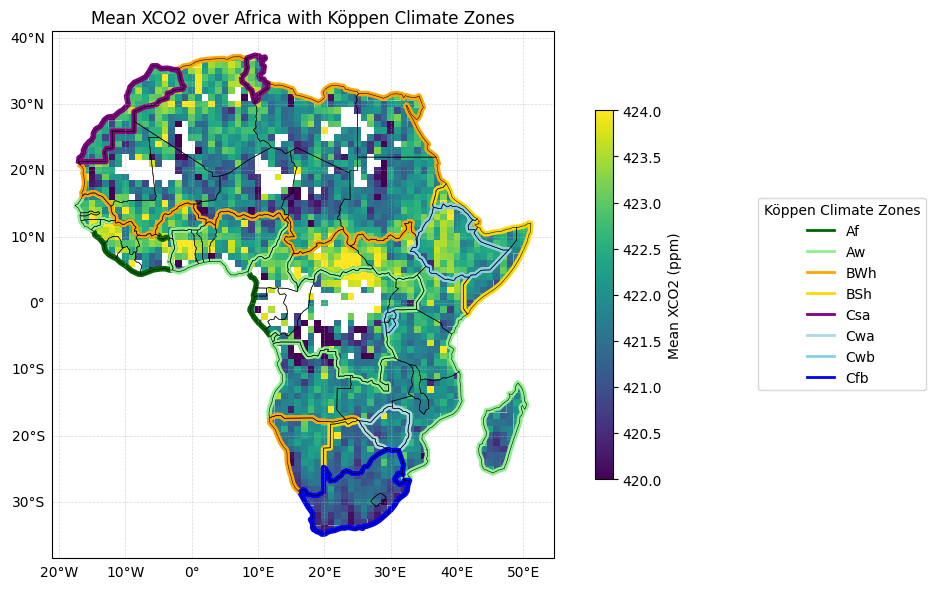

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

# Exemple de dictionnaire simplifié pour les zones Köppen en Afrique
# (il faut ajuster selon tes données réelles)
koppen_zones = {
    # 🌍 Afrique du Nord
    'Morocco': 'Csa',
    'Algeria': 'BWh',
    'Tunisia': 'Csa',
    'Libya': 'BWh',
    'Egypt': 'BWh',
    'Western Sahara': 'BWh',

    # 🌵 Sahara / Sahel
    'Mauritania': 'BWh',
    'Mali': 'BWh',
    'Niger': 'BWh',
    'Chad': 'BWh',
    'Sudan': 'BWh',
    'South Sudan': 'Aw',
    'Eritrea': 'BSh',
    'Djibouti': 'BWh',
    'Somalia': 'BSh',
    'Somaliland': 'BSh',

    # 🌴 Afrique de l’Ouest
    'Senegal': 'Aw',
    'Gambia': 'Aw',
    'Guinea-Bissau': 'Aw',
    'Guinea': 'Af',
    'Sierra Leone': 'Af',
    'Liberia': 'Af',
    'Ivory Coast': 'Af',
    'Ghana': 'Aw',
    'Togo': 'Aw',
    'Benin': 'Aw',
    'Nigeria': 'Aw',

    # 🌴 Afrique centrale
    'Cameroon': 'Af',
    'Central African Republic': 'Aw',
    'Equatorial Guinea': 'Af',
    'Gabon': 'Af',
    'Republic of the Congo': 'Af',
    'Democratic Republic of the Congo': 'Af',

    # 🌿 Afrique de l’Est
    'Ethiopia': 'Cwb',   # altitude dominante
    'Kenya': 'Aw',
    'Uganda': 'Af',
    'Rwanda': 'Cwb',
    'Burundi': 'Cwb',
    'United Republic of Tanzania': 'Aw',

    # 🌿 Afrique australe
    'Angola': 'Aw',
    'Zambia': 'Aw',
    'Zimbabwe': 'Cwa',
    'Namibia': 'BWh',
    'Botswana': 'BSh',
    'South Africa': 'Cfb',
    'Lesotho': 'Cfb',
    'Eswatini': 'Cwa',
    'Malawi': 'Aw',
    'Mozambique': 'Aw',
    'Madagascar': 'Aw',

    # 🌊 Îles
    'Seychelles': 'Af',
    'Mauritius': 'Af',
    'Comoros': 'Af'
}

# Ajouter la zone climatique Köppen à ton GeoDataFrame
gdf_with_country['koppen_zone'] = gdf_with_country['ADMIN'].map(koppen_zones)

# Appliquer aussi aux shapes pour contours
zones = africa_shape.copy()
zones['koppen_zone'] = zones['ADMIN'].map(koppen_zones)

# Enlever les pays non classés
zones_clean = zones.dropna(subset=['koppen_zone'])
zones_dissolved = zones_clean.dissolve(by='koppen_zone')

# --- Tracé ---
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Carte principale XCO2
gdf_annual.plot(
    ax=ax,
    column="xco2",
    cmap="viridis",
    vmin=420, vmax=424,
    legend=True,
    legend_kwds={'label': "Mean XCO2 (ppm)", 'shrink': 0.7}
)

# Contours des zones Köppen
koppen_colors = {
    # Tropical
    'Af': 'darkgreen',
    'Am': 'seagreen',
    'Aw': 'lightgreen',

    # Aride
    'BWh': 'orange',
    'BWk': 'peru',
    'BSh': 'gold',
    'BSk': 'khaki',

    # Tempéré
    'Csa': 'purple',
    'Csb': 'violet',
    'Cfa': 'red',
    'Cwa': 'lightblue',
    'Cwb': 'skyblue',
    'Cfb': 'blue',

    # Highland
    'H': 'grey'
}

for zone, color in koppen_colors.items():
    if zone in zones_dissolved.index:
        zones_dissolved.loc[[zone]].boundary.plot(
            ax=ax,
            edgecolor=color,
            linewidth=4,
            linestyle='-'
        )

# Légende
legend_lines = [Line2D([0], [0], color=color, lw=2, linestyle='-', label=zone)
                for zone, color in koppen_colors.items()
                if zone in zones_dissolved.index #pour afficher juste les zones présentes sur la carte
                ]

#ax.legend(handles=legend_lines, title="Köppen Climate Zones", loc='lower left') #légende à l’intérieur
fig.legend( #pour avoir la légende à l’extérieur
    handles=legend_lines,
    title="Köppen Climate Zones",
    loc='center right',
    bbox_to_anchor=(1.05, 0.5)
)

# Frontières Afrique
africa_shape.boundary.plot(ax=ax, edgecolor='black', linewidth=0.4)

# Latitude / longitude
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title("Mean XCO2 over Africa with Köppen Climate Zones")
plt.savefig("./results/annual_co2_map_koppen.png", dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

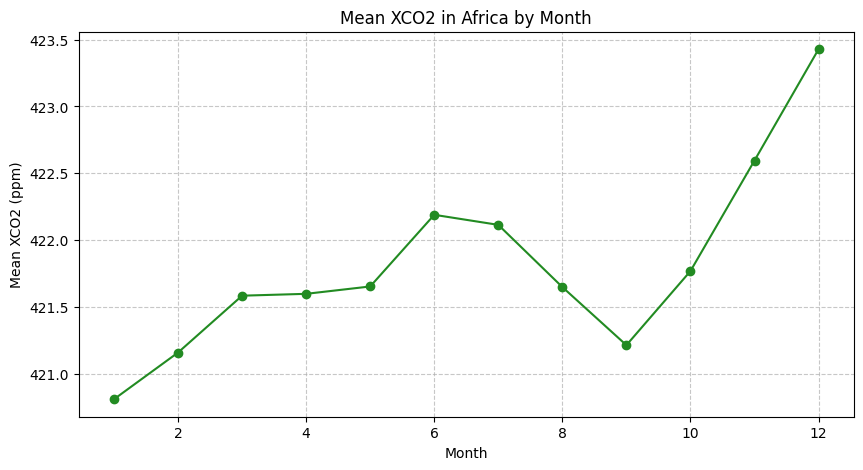

In [16]:
# 4. Monthly timeseries
plot_monthly_timeseries(df_africa)

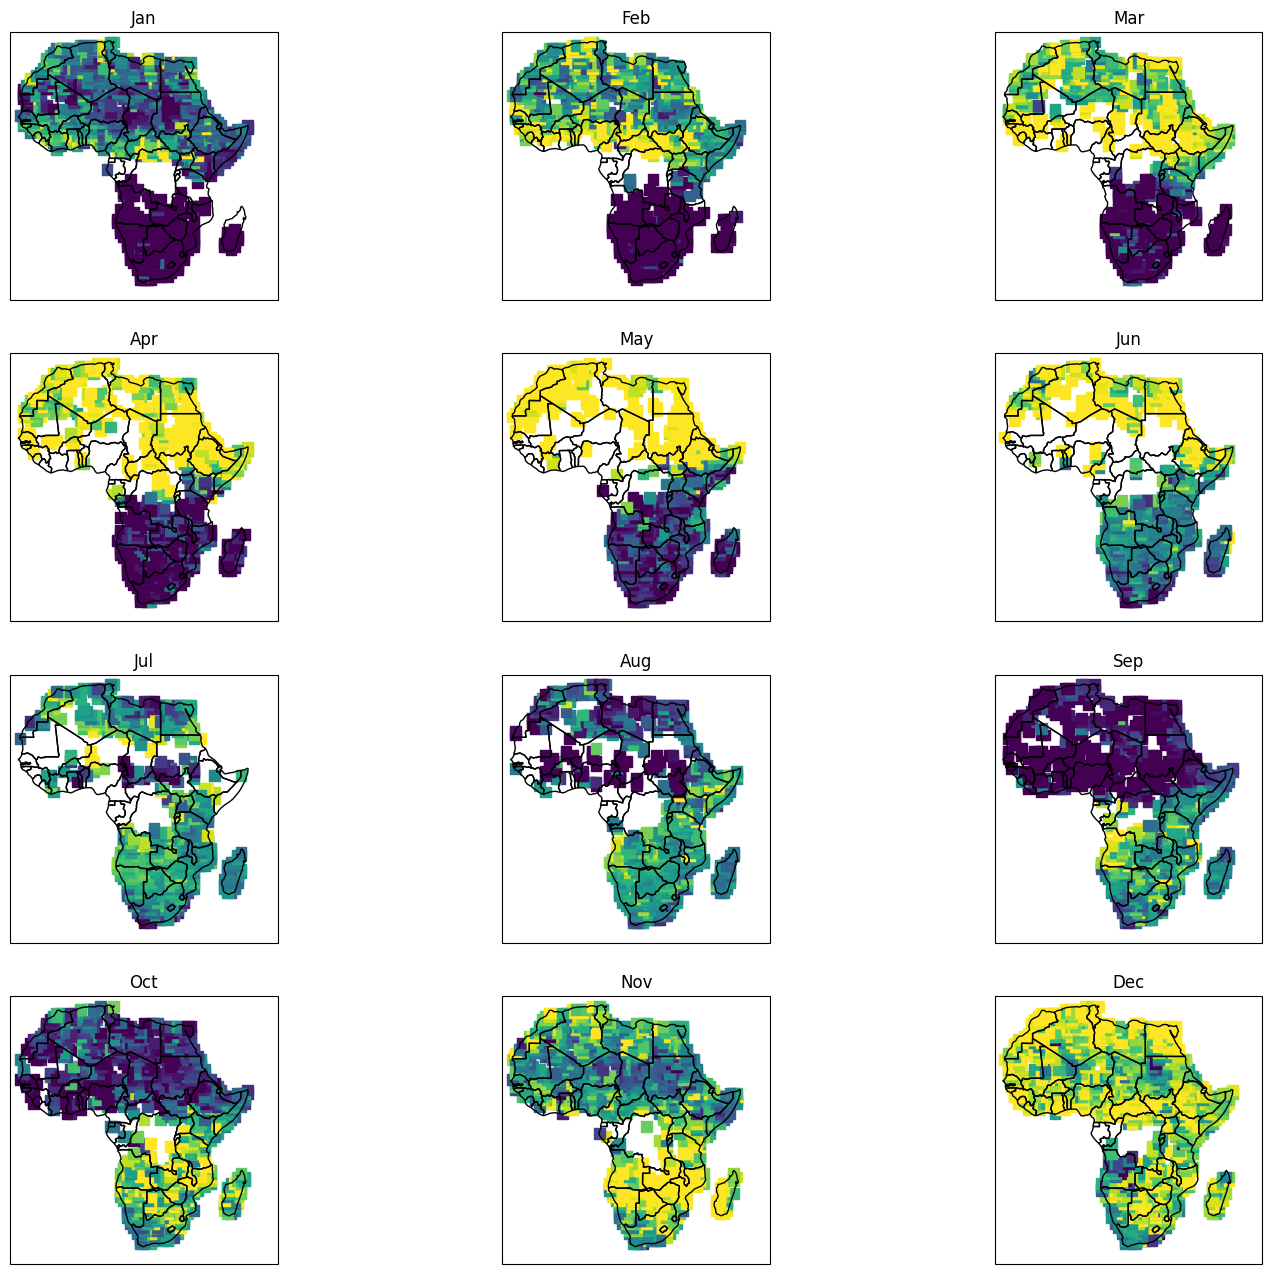

In [17]:
# --- 5. MONTHLY GRID MAPS ---
gdf_points = create_geodataframe_from_grid(df_africa)
gdf_final_points = clip_to_africa(gdf_points, africa_shape)
plot_monthly_grid(gdf_final_points, africa_shape)

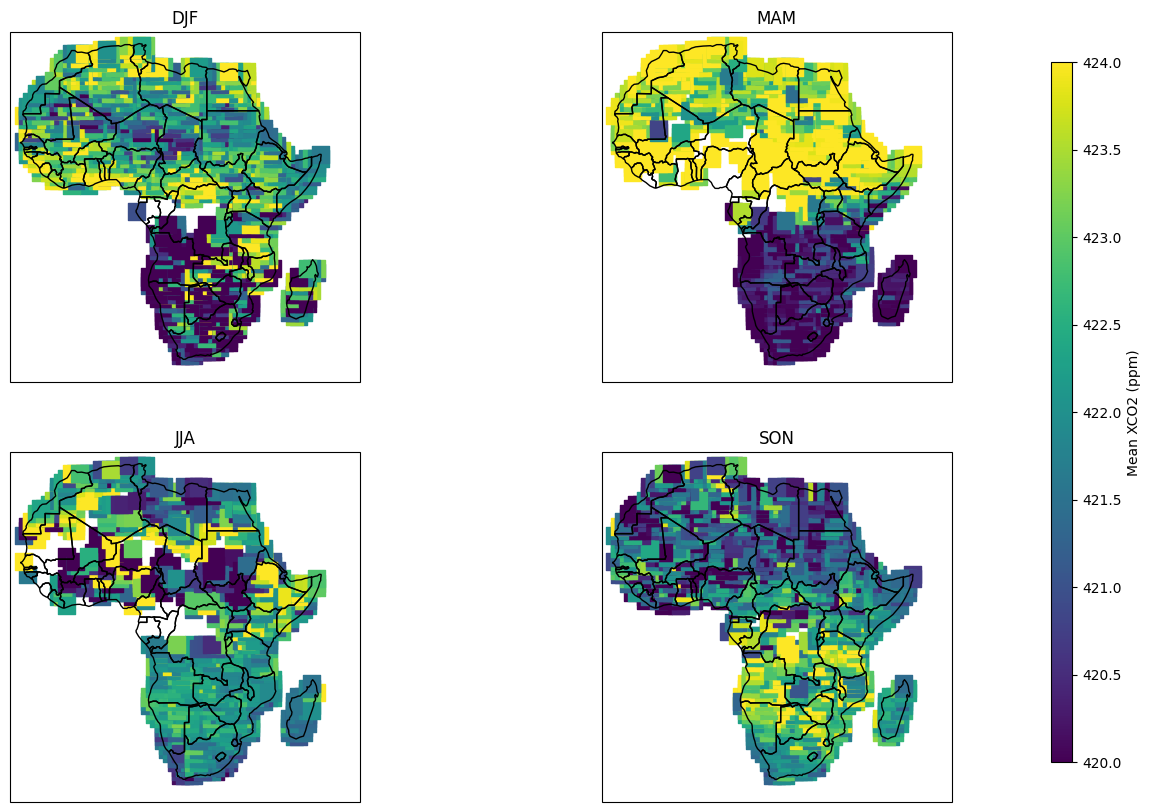

In [18]:
# --- 6. SEASONAL MAPS ---
plot_seasonal_maps(df_africa, africa_shape)

In [19]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [32]:
tif_path = "data_raster/land_cover_africa_2.tif"
with rasterio.open(tif_path) as src:
    lc_data = src.read(
        1,
        out_shape=(
            1,
            src.height // 10,   # reduce resolution by factor 10
            src.width // 10
        ),
        resampling=rasterio.enums.Resampling.nearest
    )
    # extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top] #--- IGNORE --- / I USE RASTER BOUNDS
    # Use shapefile bounds instead of raster bounds
    minx, miny, maxx, maxy = africa_shape.total_bounds
    extent = [minx, maxx, miny, maxy]
    
palette = [
    "#1d0dff00",'#05450a','#086a10','#54a708','#78d203','#009900',
    '#c6b044','#dcd159','#dade48','#fbff13','#b6ff05',
    '#27ff87','#c24f44','#a5a5a5','#ff6d4c','#69fff8',
    '#f9ffa4']
labels = ['Water','Evergreen Needleleaf Forest','Evergreen Broadleaf Forest','Deciduous Needleleaf Forest',
    'Deciduous Broadleaf Forest','Mixed Forest','Closed Shrublands','Open Shrublands',
    'Woody Savannas','Savannas','Grasslands','Permanent Wetlands','Croplands','Urban',
    'Cropland/Natural Mosaic','Snow/Ice','Barren']

#colormap
cmap = ListedColormap(palette)


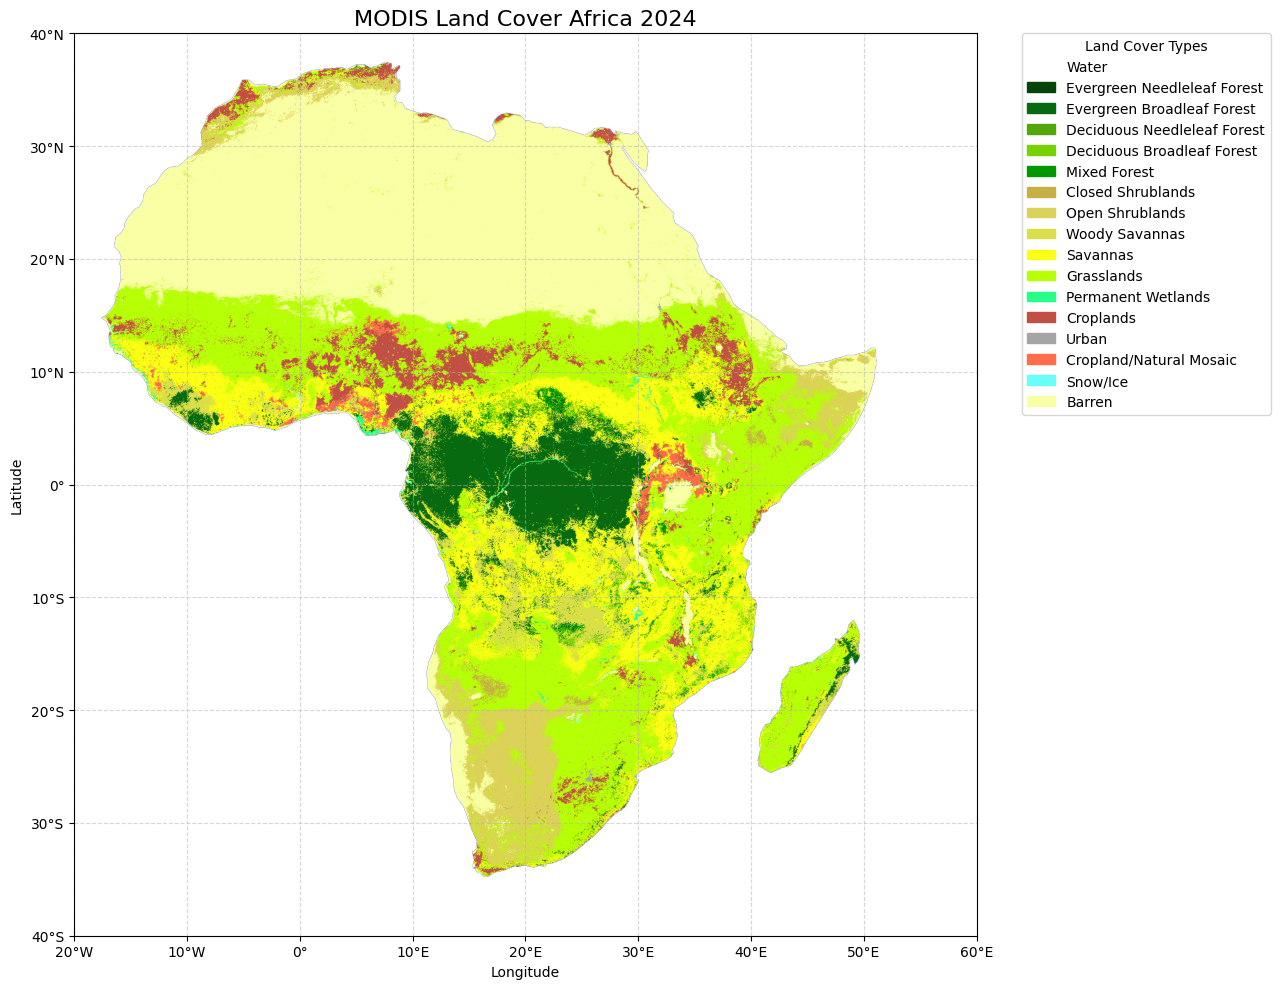

In [34]:
#plot the raster
plt.figure(figsize=(12,10))
im = plt.imshow(lc_data, cmap=cmap, vmin=0, vmax=16, extent=extent, origin='upper')
plt.title("MODIS Land Cover Africa 2024", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Gridlines 
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

plt.gca().set_xticks([-20, -10, 0, 10, 20, 30, 40, 50, 60])
plt.gca().set_yticks([-40, -30, -20, -10, 0, 10, 20, 30, 40])

plt.gca().xaxis.set_major_formatter(LongitudeFormatter())
plt.gca().yaxis.set_major_formatter(LatitudeFormatter())

plt.grid(True, linestyle='--', alpha=0.5)

# add legend
patches = [Patch(color=palette[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10, title="Land Cover Types")

plt.tight_layout()
plt.savefig("./results/land_cover_africa.png", dpi=300, bbox_inches='tight')
plt.show()

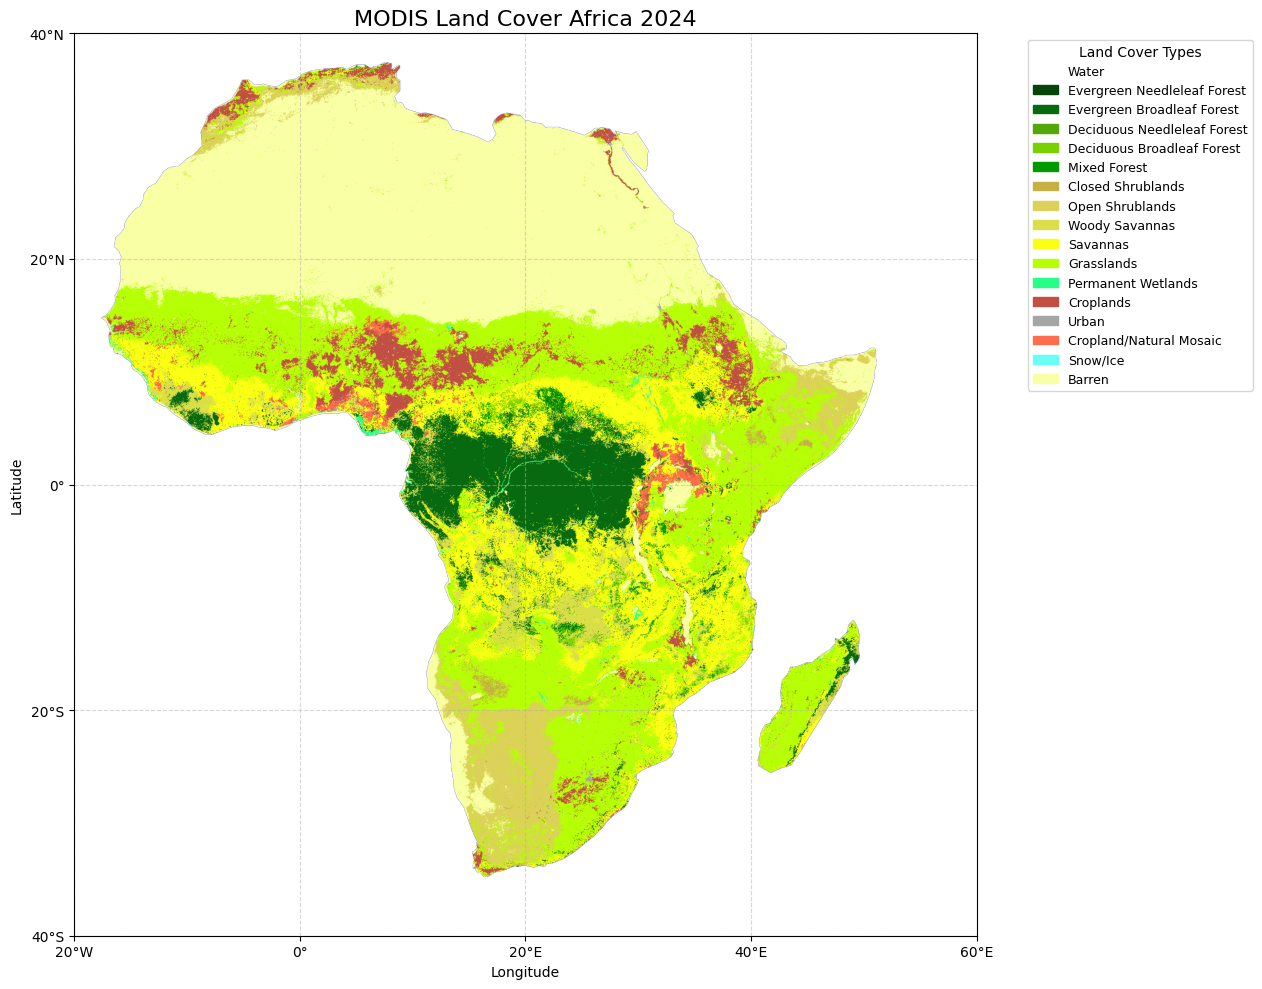

In [ ]:
def load_land_cover_raster(tif_path, scale_factor=10):
    import rasterio
    from rasterio.enums import Resampling
    
    with rasterio.open(tif_path) as src:
        lc_data = src.read(
            1,
            out_shape=(
                int(src.height / scale_factor),
                int(src.width / scale_factor)
            ),
            resampling=Resampling.nearest
        )
    return lc_data

def get_africa_extent(africa_shape):
    minx, miny, maxx, maxy = africa_shape.total_bounds
    return [minx, maxx, miny, maxy]

def get_modis_colormap():
    from matplotlib.colors import ListedColormap
    
    palette = [
        "#1d0dff00",'#05450a','#086a10','#54a708','#78d203','#009900',
        '#c6b044','#dcd159','#dade48','#fbff13','#b6ff05',
        '#27ff87','#c24f44','#a5a5a5','#ff6d4c','#69fff8',
        '#f9ffa4'
    ]
    
    labels = [
        'Water','Evergreen Needleleaf Forest','Evergreen Broadleaf Forest',
        'Deciduous Needleleaf Forest','Deciduous Broadleaf Forest','Mixed Forest',
        'Closed Shrublands','Open Shrublands','Woody Savannas','Savannas',
        'Grasslands','Permanent Wetlands','Croplands','Urban',
        'Cropland/Natural Mosaic','Snow/Ice','Barren'
    ]
    
    return ListedColormap(palette), palette, labels

def plot_land_cover(lc_data, extent, cmap, palette, labels):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import matplotlib.ticker as mticker
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

    plt.figure(figsize=(12, 10))

    plt.imshow(
        lc_data,
        cmap=cmap,
        vmin=0,
        vmax=17,
        extent=extent,
        origin='upper'
    )

    plt.title("MODIS Land Cover Africa 2024", fontsize=16)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Gridlines
    ax = plt.gca()
    plt.gca().set_xticks([-20, -10, 0, 10, 20, 30, 40, 50, 60])
    plt.gca().set_yticks([-40, -30, -20, -10, 0, 10, 20, 30, 40])
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    plt.grid(True, linestyle='--', alpha=0.5)

    # Legend
    patches = [Patch(color=palette[i], label=labels[i]) for i in range(len(labels))]
    plt.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=9,
        title="Land Cover Types"
    )

    plt.tight_layout()
    plt.savefig("./results/land_cover_africa.png", dpi=300, bbox_inches='tight')
    plt.show()

lc_data = load_land_cover_raster("data_raster/land_cover_africa_2.tif")
extent = get_africa_extent(africa_shape)
cmap, palette, labels = get_modis_colormap()

plot_land_cover(lc_data, extent, cmap, palette, labels)